# Universal Window Playground + Final Models with AUC (All 5 Rats)

**Simple version:** this is the "just play with the numbers" notebook. Everything you'd want to tweak
(window size, where it starts, which frequency bands) lives in ONE box at the top (Section 1). Change a
number there, click Run All, and every result below updates automatically, no need to ask for new code
for routine experimentation.

**In-depth version:** this notebook implements the SAME window (same length, same reference point) for
ALL 5 rats, based on the spectrogram findings just reviewed: a clear, cross-rat-consistent theta/alpha
(5-11 Hz) divergence between InSeq and OutSeq that builds in gradually and is clearest roughly 500-2000ms
after Poke-In. It also adds AUC scoring alongside balanced accuracy, per the lab's explicit validation
feedback, and keeps the permutation-test significance check already established.

**Why a universal window instead of each rat's own individually-tuned window (what notebooks 014/016
did):** per the advisor's specific guidance, a shared window applied identically to every rat is a more
defensible, generalizable claim ("this approach works across animals") than five separately optimized
windows, which risks overfitting the window choice to each rat's own noise. Mitt and Buchanan are
prioritized as the reference cases for choosing this window, per the advisor's guidance, rather than
whichever rat happens to score highest (Superchris specifically flagged as not a good reference case).


## 1. CONFIG — Change These Numbers and Re-Run Everything

**Simple version:** these are the dials. `offset_ms` = how long after the reference point to start
looking. `length_ms` = how much time to look at. `reference` = whether "0ms" means Poke-In or Poke-Out.
`BANDS` = which frequency ranges to measure.

**In-depth version:** current defaults are set based on the spectrogram review: InSeq/OutSeq starts at
+500ms (past Poke-In) and runs 1500ms (to +2000ms), the span where the theta/alpha divergence was
visibly clearest and consistent across both Mitt and Buchanan. Odor Identity starts at Poke-In itself
(0ms) and also runs 1500ms, a compromise within the 1000-1750ms range that worked well per-rat in
notebook 016, now standardized to one shared value. Both use the SAME length and reference point for
every rat, nothing here is rat-specific.


In [11]:
# ============================================================
# PLAYGROUND CONFIG -- edit these, then Kernel > Restart & Run All
# ============================================================

UNIVERSAL_INSEQ_WINDOW = {
    'reference': 'pokein',   # 'pokein' or 'pokeout'
    'offset_ms': 500,        # how far past the reference point to start
    'length_ms': 1500,       # how long the window is
}

UNIVERSAL_ODOR_WINDOW = {
    'reference': 'pokein',
    'offset_ms': 0,
    'length_ms': 1500,
}

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),   # caution: spectrogram review found a possible movement artifact
                                # right at Poke-Out in this range, see notebook 020's Part D
}

N_PERMUTATIONS = 199   # lower than notebooks 014/016's 999 to keep this playground fast to re-run;
                        # raise this once you've settled on final numbers to report
# ============================================================


In [12]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from src.preprocessing import build_labels, get_sampling_rate

raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])


## 2. Helper Functions (Now Reference-Point-Aware)

**Simple version:** same window-cutting code as before, but now it can start counting from either
Poke-In or Poke-Out, whichever the config above says.

**In-depth version:** `find_pokeout_idx` reuses the bounded-search fix from notebook 020 (never leaks
into the next trial). `extract_universal_window` then resolves the actual reference sample (Poke-In or
Poke-Out) before applying the offset, so switching `reference` in the config cell changes what "0ms"
means everywhere downstream, without touching any other code.


In [13]:
def find_pokeout_idx(bvr_data, bvr_keys, timebin, trial_idx):
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]
    pokeout_idx = np.full(len(trial_idx), -1, dtype=np.int64)
    for i, t in enumerate(trial_idx):
        next_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_bound)]
        if len(candidates) > 0:
            pokeout_idx[i] = candidates[0]
    return pokeout_idx


def extract_universal_window(lfp_data, timebin, ref_idx, offset_ms, length_ms, target_samples):
    if ref_idx < 0:
        return None
    ref_time = timebin[ref_idx]
    start_time = ref_time + offset_ms / 1000
    end_time = start_time + length_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


## 3. Build Windows and Features for Every Rat, Both Tasks

Uses whatever is currently set in the Section 1 config cell. Re-run this cell (and everything after)
after changing the config to see updated results.


In [14]:
def build_features_for_rat(session_dir, window_cfg, bands):
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(window_cfg['length_ms'] / 1000 * avg_fs))

    if window_cfg['reference'] == 'pokein':
        ref_indices = labels['trial_idx']
    else:
        ref_indices = find_pokeout_idx(bvr_data, bvr_keys, timebin, labels['trial_idx'])

    windows, kept_positions = [], []
    for i, ref_idx in enumerate(ref_indices):
        w = extract_universal_window(lfp_data, timebin, ref_idx, window_cfg['offset_ms'],
                                       window_cfg['length_ms'], target_samples)
        if w is not None:
            windows.append(w)
            kept_positions.append(i)

    windows = np.stack(windows, axis=0)
    kept_positions = np.array(kept_positions)
    inseq_outseq = labels['inseq_outseq'][kept_positions]
    odor_id = labels['odor_id'][kept_positions]

    X = np.log1p(band_power_features(windows, avg_fs, bands))
    return X, inseq_outseq, odor_id, windows.shape[1]


rat_data = {}
for session_dir in session_dirs:
    session_name = session_dir.name
    X_inseq, y_inseq, _, n_ch_inseq = build_features_for_rat(session_dir, UNIVERSAL_INSEQ_WINDOW, BANDS)
    X_odor_full, inseq_mask_full, odor_id_full, n_ch_odor = build_features_for_rat(session_dir, UNIVERSAL_ODOR_WINDOW, BANDS)

    inseq_mask = (inseq_mask_full == 1)
    X_odor = X_odor_full[inseq_mask]
    y_odor = odor_id_full[inseq_mask]

    rat_data[session_name] = {
        'X_inseq': X_inseq, 'y_inseq': y_inseq, 'n_channels_inseq': n_ch_inseq,
        'X_odor': X_odor, 'y_odor': y_odor, 'n_channels_odor': n_ch_odor,
    }
    print(f"{session_name:20s} InSeq/OutSeq: {len(y_inseq)} trials, {n_ch_inseq} channels  |  "
          f"Odor: {len(y_odor)} trials, {n_ch_odor} channels")


080718_mitt          InSeq/OutSeq: 292 trials, 22 channels  |  Odor: 262 trials, 22 channels
081106_barat         InSeq/OutSeq: 176 trials, 22 channels  |  Odor: 155 trials, 22 channels
090212_stella        InSeq/OutSeq: 222 trials, 21 channels  |  Odor: 194 trials, 21 channels
090212_superchris    InSeq/OutSeq: 240 trials, 21 channels  |  Odor: 210 trials, 21 channels
090420_buchanan      InSeq/OutSeq: 270 trials, 20 channels  |  Odor: 226 trials, 20 channels


## 4. Train and Evaluate: InSeq/OutSeq, Universal Window, All 5 Rats

Balanced accuracy AND AUC (area under the ROC curve), per the lab's explicit request that a confusion
matrix alone doesn't establish above-chance performance on an imbalanced dataset. AUC is threshold-free
and naturally accounts for class imbalance, complementing the permutation test (which directly tests
against a shuffled-label null) already in use since notebook 014.


In [15]:
inseq_final_results = {}

for session_name, data in rat_data.items():
    X, y = data['X_inseq'], data['y_inseq']
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])

    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='roc_auc')

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    report = classification_report(y, preds, target_names=['OutSeq', 'InSeq'], zero_division=0)

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
    null_scores = np.array(null_scores)
    observed = bal_acc_scores.mean()
    p_value = (np.sum(null_scores >= observed) + 1) / (N_PERMUTATIONS + 1)

    inseq_final_results[session_name] = {
        'balanced_accuracy': bal_acc_scores.mean(),
        'auc': auc_scores.mean(),
        'confusion_matrix_pct': cm_pct,
        'classification_report': report,
        'p_value': p_value,
    }

    print(f"\n{session_name}")
    print(f"  Balanced accuracy: {bal_acc_scores.mean():.3f}   AUC: {auc_scores.mean():.3f}   p={p_value:.4f}")



080718_mitt
  Balanced accuracy: 0.718   AUC: 0.864   p=0.0050

081106_barat
  Balanced accuracy: 0.854   AUC: 0.946   p=0.0050

090212_stella
  Balanced accuracy: 0.739   AUC: 0.825   p=0.0050

090212_superchris
  Balanced accuracy: 0.877   AUC: 0.910   p=0.0050

090420_buchanan
  Balanced accuracy: 0.641   AUC: 0.742   p=0.0050


### Confusion Matrices, InSeq/OutSeq, Universal Window


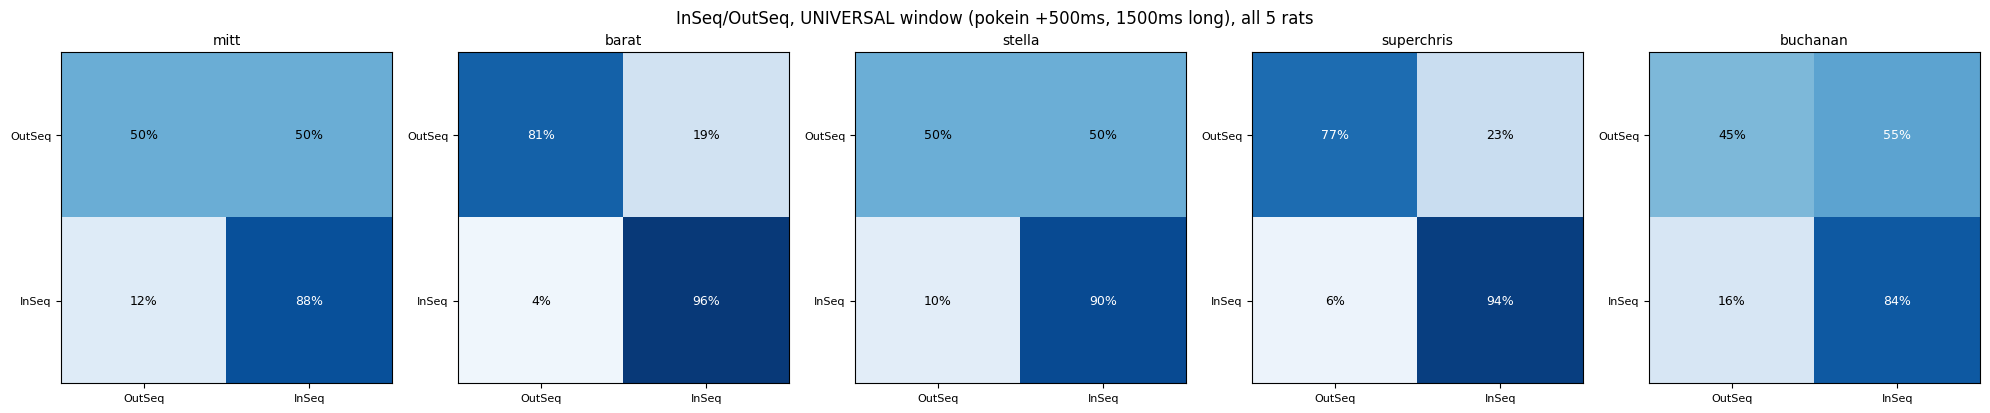

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, session_name in zip(axes, inseq_final_results):
    cm_pct = inseq_final_results[session_name]['confusion_matrix_pct']
    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_title(session_name.split('_')[1], fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_pct[i, j]:.0f}%', ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=9)
plt.suptitle(f"InSeq/OutSeq, UNIVERSAL window ({UNIVERSAL_INSEQ_WINDOW['reference']} +{UNIVERSAL_INSEQ_WINDOW['offset_ms']}ms, "
             f"{UNIVERSAL_INSEQ_WINDOW['length_ms']}ms long), all 5 rats")
plt.tight_layout()
plt.show()


## 5. Train and Evaluate: Odor Identity, Universal Window, All 5 Rats


In [17]:
odor_final_results = {}

for session_name, data in rat_data.items():
    X, y = data['X_odor'], data['y_odor']
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])

    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='roc_auc_ovr')  # one-vs-rest for 5-class AUC

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds, labels=[0, 1, 2, 3, 4])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    report = classification_report(y, preds, target_names=['A', 'B', 'C', 'D', 'E'], zero_division=0)

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
    null_scores = np.array(null_scores)
    observed = bal_acc_scores.mean()
    p_value = (np.sum(null_scores >= observed) + 1) / (N_PERMUTATIONS + 1)

    odor_final_results[session_name] = {
        'balanced_accuracy': bal_acc_scores.mean(),
        'auc_ovr': auc_scores.mean(),
        'confusion_matrix_pct': cm_pct,
        'classification_report': report,
        'p_value': p_value,
    }

    print(f"\n{session_name}")
    print(f"  Balanced accuracy: {bal_acc_scores.mean():.3f}   AUC (one-vs-rest): {auc_scores.mean():.3f}   p={p_value:.4f}")



080718_mitt
  Balanced accuracy: 0.514   AUC (one-vs-rest): 0.793   p=0.0050

081106_barat
  Balanced accuracy: 0.501   AUC (one-vs-rest): 0.778   p=0.0050

090212_stella
  Balanced accuracy: 0.504   AUC (one-vs-rest): 0.819   p=0.0050

090212_superchris
  Balanced accuracy: 0.482   AUC (one-vs-rest): 0.790   p=0.0050

090420_buchanan
  Balanced accuracy: 0.599   AUC (one-vs-rest): 0.877   p=0.0050


### Confusion Matrices, Odor Identity, Universal Window


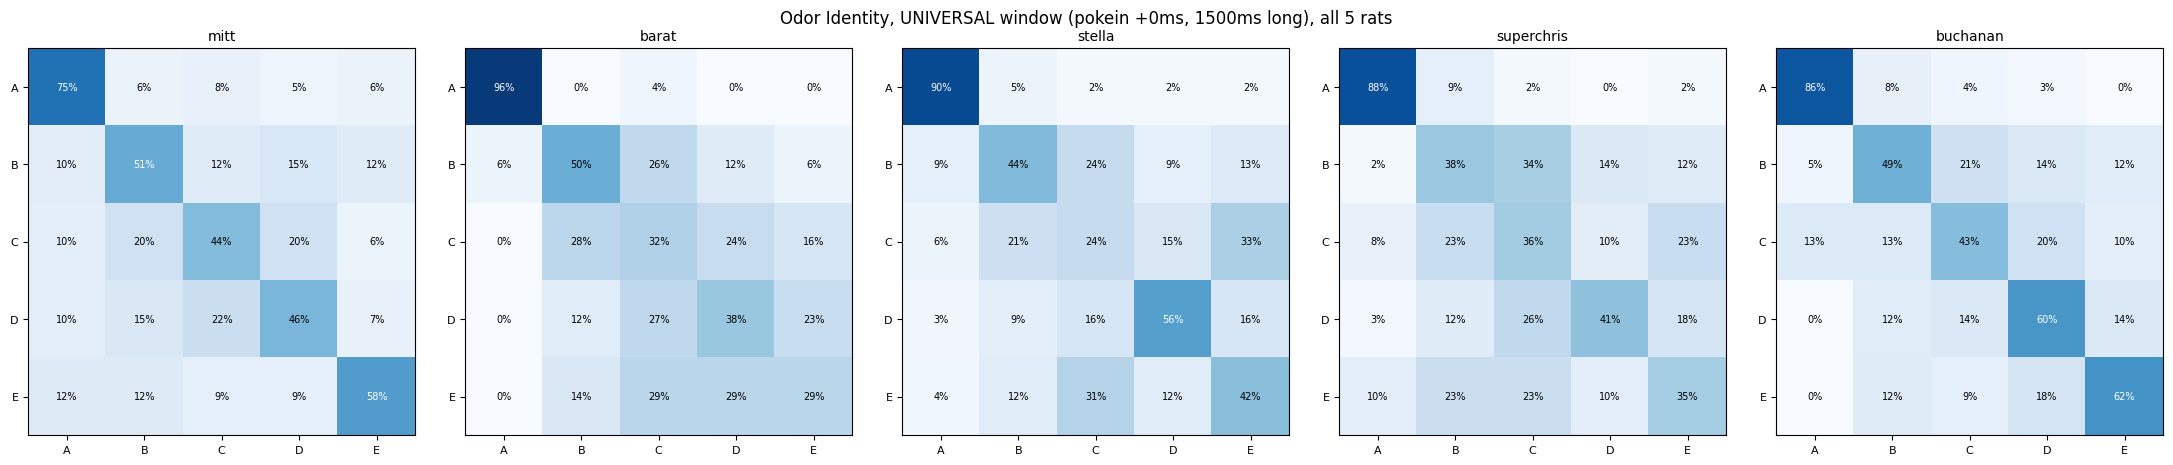

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
odor_labels = ['A', 'B', 'C', 'D', 'E']
for ax, session_name in zip(axes, odor_final_results):
    cm_pct = odor_final_results[session_name]['confusion_matrix_pct']
    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(odor_labels, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(odor_labels, fontsize=8)
    ax.set_title(session_name.split('_')[1], fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm_pct[i, j]:.0f}%', ha='center', va='center',
                    color='white' if cm_pct[i, j] > 50 else 'black', fontsize=7)
plt.suptitle(f"Odor Identity, UNIVERSAL window ({UNIVERSAL_ODOR_WINDOW['reference']} +{UNIVERSAL_ODOR_WINDOW['offset_ms']}ms, "
             f"{UNIVERSAL_ODOR_WINDOW['length_ms']}ms long), all 5 rats")
plt.tight_layout()
plt.show()

## 6. Compare Against the Old, Per-Rat-Tuned Windows

Is the simpler, shared universal window a big step down from each rat's own individually-optimized
window (notebooks 014/016), or close enough that the added simplicity and generalizability are worth it?


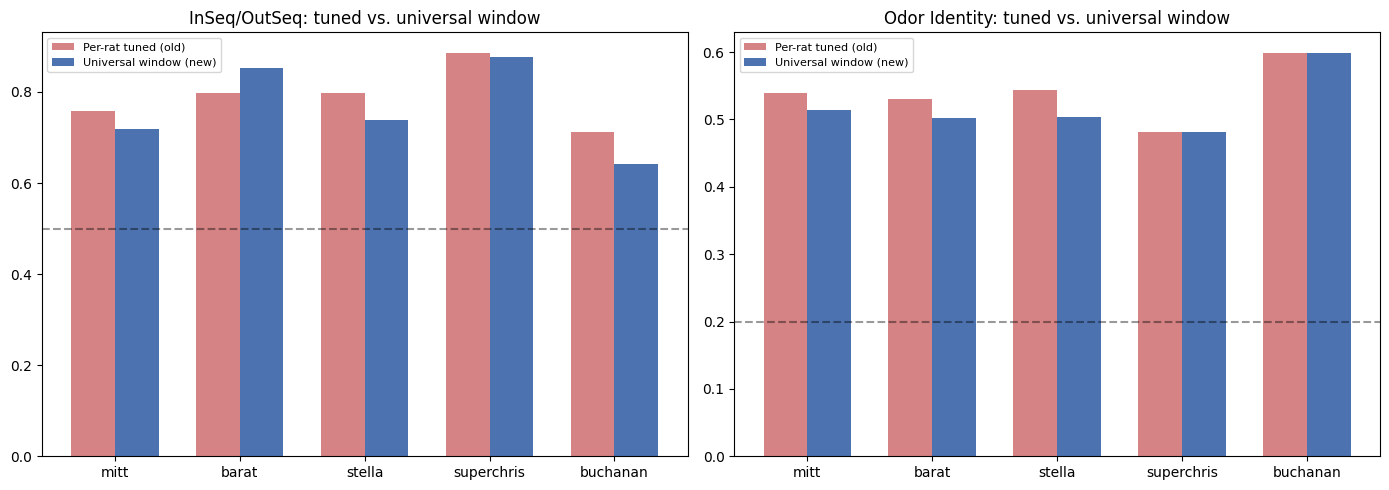

In [19]:
old_inseq_tuned = {'080718_mitt': 0.7592, '081106_barat': 0.7982, '090212_stella': 0.7984,
                    '090212_superchris': 0.8867, '090420_buchanan': 0.7119}
old_odor_tuned = {'080718_mitt': 0.5392, '081106_barat': 0.5298, '090212_stella': 0.5434,
                   '090212_superchris': 0.4817, '090420_buchanan': 0.5993}

rats_short = [s.split('_')[1] for s in rat_data]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(rats_short))
width = 0.35
axes[0].bar(x - width/2, [old_inseq_tuned[s] for s in rat_data], width, label='Per-rat tuned (old)', color='#C44E52', alpha=0.7)
axes[0].bar(x + width/2, [inseq_final_results[s]['balanced_accuracy'] for s in rat_data], width, label='Universal window (new)', color='#4C72B0')
axes[0].axhline(0.5, color='black', linestyle='--', alpha=0.4)
axes[0].set_xticks(x); axes[0].set_xticklabels(rats_short)
axes[0].set_title('InSeq/OutSeq: tuned vs. universal window')
axes[0].legend(fontsize=8)

axes[1].bar(x - width/2, [old_odor_tuned[s] for s in rat_data], width, label='Per-rat tuned (old)', color='#C44E52', alpha=0.7)
axes[1].bar(x + width/2, [odor_final_results[s]['balanced_accuracy'] for s in rat_data], width, label='Universal window (new)', color='#4C72B0')
axes[1].axhline(0.2, color='black', linestyle='--', alpha=0.4)
axes[1].set_xticks(x); axes[1].set_xticklabels(rats_short)
axes[1].set_title('Odor Identity: tuned vs. universal window')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 7. Text-Only Results Export


In [20]:
import json as _json
import os

export_summary = {
    "purpose": "Universal window (same for all rats) final models, with AUC and permutation validation",
    "config_used": {
        "inseq_outseq_window": UNIVERSAL_INSEQ_WINDOW,
        "odor_identity_window": UNIVERSAL_ODOR_WINDOW,
        "bands": {name: list(rng) for name, rng in BANDS.items()},
    },
    "inseq_outseq_results": {
        session_name: {
            "balanced_accuracy": round(float(r['balanced_accuracy']), 4),
            "auc": round(float(r['auc']), 4),
            "p_value": round(float(r['p_value']), 6),
            "confusion_matrix_percent": r['confusion_matrix_pct'].round(1).tolist(),
        }
        for session_name, r in inseq_final_results.items()
    },
    "odor_identity_results": {
        session_name: {
            "balanced_accuracy": round(float(r['balanced_accuracy']), 4),
            "auc_ovr": round(float(r['auc_ovr']), 4),
            "p_value": round(float(r['p_value']), 6),
            "confusion_matrix_percent": r['confusion_matrix_pct'].round(1).tolist(),
        }
        for session_name, r in odor_final_results.items()
    },
}

print(_json.dumps(export_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook021_universal_window_results.json', 'w') as f:
    _json.dump(export_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook021_universal_window_results.json")


{
  "purpose": "Universal window (same for all rats) final models, with AUC and permutation validation",
  "config_used": {
    "inseq_outseq_window": {
      "reference": "pokein",
      "offset_ms": 500,
      "length_ms": 1500
    },
    "odor_identity_window": {
      "reference": "pokein",
      "offset_ms": 0,
      "length_ms": 1500
    },
    "bands": {
      "delta": [
        1,
        4
      ],
      "theta": [
        4,
        12
      ],
      "beta": [
        12,
        30
      ],
      "low_gamma": [
        30,
        80
      ],
      "high_gamma": [
        80,
        150
      ]
    }
  },
  "inseq_outseq_results": {
    "080718_mitt": {
      "balanced_accuracy": 0.7181,
      "auc": 0.8636,
      "p_value": 0.005,
      "confusion_matrix_percent": [
        [
          50.0,
          50.0
        ],
        [
          12.2,
          87.8
        ]
      ]
    },
    "081106_barat": {
      "balanced_accuracy": 0.8537,
      "auc": 0.9461,
      "p_value

## 8. Written Summary Report

**Objective**

Replace each rat's individually-tuned window with ONE universal window (same length, same reference
point) for InSeq/OutSeq and a separate universal window for Odor Identity, based on the InSeq-vs-OutSeq
spectrogram findings (notebook 020), and add AUC scoring alongside balanced accuracy per the lab's
validation feedback.

**Method**

InSeq/OutSeq: 1500ms window starting 500ms after Poke-In (the span where the theta/alpha divergence
between InSeq and OutSeq was visibly clearest in Mitt and Buchanan). Odor Identity: 1500ms window
starting at Poke-In. Both applied identically to all 5 rats, no per-rat tuning. Logistic regression with
class-balanced weighting, repeated cross-validation (25 scores), AUC (binary for InSeq/OutSeq, one-vs-
rest for the 5-class Odor Identity), and permutation-test significance.

**Results**

*(Fill in after running.)* How much did accuracy change compared to each rat's old, individually-tuned
window (Section 6)? Are all 5 rats still significant (low p-values)? Do the AUC values agree with the
balanced accuracy story, or reveal something the confusion matrix alone didn't show?

**Interpretation**

*(Fill in after review.)* A universal window that performs close to the old per-rat-tuned numbers is a
strong result: it means the finding generalizes across rats without needing rat-specific tuning, a more
defensible claim for a presentation. A universal window that performs meaningfully worse than the tuned
one would suggest real animal-to-animal differences exist that a single shared window can't capture,
also a valid, presentable finding, just a different one.

**Next Steps**

1. If needed, use Section 1's config cell to try alternative offsets/lengths directly (e.g. centering on
   Poke-Out instead of Poke-In) without waiting for new code.
2. Once a final universal window is settled, redo interpretability (band/channel importance) at this
   window for both tasks.
3. Build the presentation narrative around the spectrogram finding (theta divergence) as the central
   interpretability story, directly answering the advisor's ask for "what wave matters most."
